<a href="https://colab.research.google.com/github/Raanank10/UK_Used_Car_Data/blob/main/notebooks/toyota_used_car_pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pricing Used Toyotas in the UK: Depreciation, Premiums and a Fair-Price Model

**Business context.** A used-car dealer specialising in Toyota needs to answer three questions every day:
1. **What is this car worth?** It needs a fair price *range* for trade-ins and listings, not a single number.
2. **What drives value?** Age, mileage, gearbox, hybrid or not: how much is each one worth in £?
3. **Which listings are mispriced?** Cars listed far below fair value are buying opportunities. Cars listed above it will sit on the forecourt.

**Data.** 6,738 UK Toyota listings from the Kaggle "100,000 UK Used Car Data set" (scraped around 2020): model, registration year, price, gearbox, mileage, fuel type, road tax, mpg and engine size.

**Approach.** SQL for the business cuts, a log-price regression for interpretable effects, and gradient boosting with 5-fold cross-validation for the fair-price model.

In [1]:
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import HistGradientBoostingRegressor

import os, subprocess
if not Path('data').exists() and not Path('../data').exists():   # e.g. running in Colab
    subprocess.run(['git', 'clone', '-q', 'https://github.com/Raanank10/UK_Used_Car_Data.git'], check=True)
    os.chdir('UK_Used_Car_Data')
ROOT = Path('..') if Path('../data').exists() else Path('.')
SEED = 42
DATA_YEAR = 2020  # newest registration year in the scrape, used to compute age
pd.set_option('display.width', 160)

## 1. Load and clean

In [2]:
raw = pd.read_csv(ROOT / 'data' / 'toyota.csv')
df = raw.copy()
df['model'] = df['model'].str.strip()          # source has leading spaces (' Yaris')
n_dupes = df.duplicated().sum()
df = df.drop_duplicates()
df = df[df['transmission'] != 'Other']          # a single unusable row
df['age'] = DATA_YEAR - df['year']
df = df.reset_index(drop=True)
print(f'Raw rows: {len(raw):,} | exact duplicates removed: {n_dupes} | clean rows: {len(df):,}')
df.describe().T.round(1)

Raw rows: 6,738 | exact duplicates removed: 39 | clean rows: 6,698


,count,mean,std,min,25%,50%,75%,max
year,6698.0,2016.7,2.2,1998.0,2016.0,2017.0,2018.0,2020.0
price,6698.0,12529.8,6359.0,850.0,8265.8,10796.5,14995.0,59995.0
mileage,6698.0,22890.5,19110.6,2.0,9486.2,18571.5,31059.8,174419.0
tax,6698.0,94.6,73.9,0.0,0.0,135.0,145.0,565.0
mpg,6698.0,63.1,15.9,2.8,55.4,62.8,70.6,235.0
engineSize,6698.0,1.5,0.4,0.0,1.0,1.5,1.8,4.5
age,6698.0,3.3,2.2,0.0,2.0,3.0,4.0,22.0


Quick checks before modelling:
- **Duplicates matter.** If the same listing appears twice, one copy can land in training and the other in testing, which inflates accuracy. They are removed above.
- **Very high mpg values (134-235) on some Prius listings are real.** They are plug-in hybrids, so they're kept.
- **Six listings report a 0.0L engine.** These are data-entry gaps. Tree models handle them, and they're too few to move the regression.

## 2. Business cuts in SQL

In [3]:
con = sqlite3.connect(':memory:')
df.drop(columns=['age']).to_sql('listings', con, index=False)
run_sql = lambda f: pd.read_sql((ROOT / 'sql' / f).read_text(), con)
run_sql('01_inventory_mix.sql')

,model,listings,share_pct,avg_price,avg_age_years,avg_mileage,hybrid_pct
0,Yaris,2116,31.8,10548.0,3.3,21384.0,26.2
1,Aygo,1940,29.2,7887.0,3.0,18116.0,0.0
2,Auris,709,10.7,12525.0,4.3,32735.0,70.2
3,C-HR,479,7.2,20652.0,2.2,17919.0,73.5
4,RAV4,467,7.0,18200.0,4.1,35265.0,48.8
5,Corolla,265,4.0,20973.0,1.4,9567.0,68.3
6,Prius,232,3.5,18999.0,3.8,31424.0,92.2
7,Avensis,114,1.7,9878.0,5.0,47461.0,0.0
8,Verso,114,1.7,12169.0,4.2,28481.0,0.0
9,Hilux,85,1.3,21581.0,2.5,27799.0,0.0


Yaris and Aygo make up **61% of listings**. That's the core of the market, and the price model needs to be strongest there.

In [4]:
dep = run_sql('02_depreciation_by_model.sql')
dep[dep.model.isin(['Yaris', 'Aygo', 'Auris', 'C-HR'])]

,model,age,n,avg_price,avg_mileage,yoy_change_pct,value_index_vs_age1
0,Auris,2,57,15273.0,20893.0,NaN,100.0
1,Auris,3,218,14088.0,24971.0,-7.8,92.2
2,Auris,4,154,12706.0,31914.0,-9.8,83.2
3,Auris,5,115,11933.0,36953.0,-6.1,78.1
4,Auris,6,94,10772.0,41027.0,-9.7,70.5
5,Auris,7,47,9153.0,43834.0,-15.0,59.9
8,Aygo,1,362,9805.0,4816.0,NaN,100.0
9,Aygo,2,376,8412.0,13845.0,-14.2,85.8
10,Aygo,3,646,7691.0,19136.0,-8.6,78.4
11,Aygo,4,240,7047.0,22934.0,-8.4,71.9


The window function (`LAG`) shows a typical Yaris losing **6-12% of its value a year**, with a cumulative ~44% loss by age 7. Two cautions:
- These raw averages mix in mileage, which also rises with age (section 3 separates the two effects).
- Jumps like RAV4 between ages 1 and 3 (-39%) reflect the **2019 model-generation change**, not normal depreciation. A raw year-over-year cut can't tell those apart, and a reviewer should know that.

In [5]:
hyb = run_sql('03_hybrid_premium_matched.sql')
hyb

,model,year,hybrid_n,petrol_n,hybrid_avg_price,petrol_avg_price,hybrid_premium_pct,mileage_gap
0,Auris,2013,28,15,10553.0,7243.0,45.7,-1186.0
1,Auris,2014,70,20,11706.0,8281.0,41.4,13831.0
2,Auris,2015,92,14,12734.0,8814.0,44.5,-2132.0
3,Auris,2016,106,29,14011.0,10214.0,37.2,4121.0
4,Auris,2017,150,63,15455.0,11141.0,38.7,5808.0
5,Auris,2018,42,15,16311.0,12365.0,31.9,2728.0
6,C-HR,2017,147,67,20048.0,16059.0,24.8,1328.0
7,C-HR,2018,106,33,21176.0,17751.0,19.3,2636.0
8,C-HR,2019,88,17,24990.0,19265.0,29.7,-2522.0
9,Corolla,2019,156,68,22599.0,17920.0,26.1,2522.0


Compared like for like (same model, same registration year), hybrids list **20-50% above petrol**, and **the gap is wider for older cars**. For the Yaris it falls from 52% (2013) to 21% (2019).

But hybrids are always automatic and usually have bigger engines. How much of the "premium" is really the hybrid? The regression answers that.

## 3. What drives price? (interpretable log-price regression)

In [6]:
reg = df[df.age <= 8].copy()
reg['log_price'] = np.log(reg['price'])
reg['miles_10k'] = reg['mileage'] / 1e4
reg['hybrid'] = (reg['fuelType'] == 'Hybrid').astype(int)
reg['automatic'] = (reg['transmission'] != 'Manual').astype(int)

ols = smf.ols(
    'log_price ~ C(model) * age + miles_10k + automatic + engineSize + hybrid + hybrid:age',
    data=reg[reg.model.isin(['Yaris', 'Aygo', 'Auris', 'C-HR', 'RAV4', 'Corolla', 'Prius'])],
).fit(cov_type='HC3')

pct = lambda x: 100 * (np.exp(x) - 1)
terms = {'automatic': 'Automatic vs manual gearbox',
         'miles_10k': 'Each extra 10,000 miles',
         'engineSize': 'Each extra 1.0L of engine',
         'hybrid': 'Hybrid at age 0',
         'hybrid:age': 'Hybrid: extra value kept per year of age'}
effects = pd.DataFrame({
    'effect_pct': [pct(ols.params[t]) for t in terms],
    'ci_low': [pct(ols.conf_int().loc[t, 0]) for t in terms],
    'ci_high': [pct(ols.conf_int().loc[t, 1]) for t in terms],
}, index=list(terms.values())).round(1)
print(f'R² = {ols.rsquared:.3f} on {int(ols.nobs):,} listings (age ≤ 8, 7 core models, model-specific depreciation slopes)')
effects

R² = 0.953 on 6,077 listings (age ≤ 8, 7 core models, model-specific depreciation slopes)


,effect_pct,ci_low,ci_high
Automatic vs manual gearbox,15.9,15.0,16.8
"Each extra 10,000 miles",-4.7,-4.9,-4.5
Each extra 1.0L of engine,15.0,11.7,18.4
Hybrid at age 0,0.6,-1.1,2.4
Hybrid: extra value kept per year of age,3.3,2.9,3.8


In [7]:
yaris_age = pct(ols.params['age'])  # Yaris is the reference model
print(f'Yaris, petrol: {yaris_age:.1f}% per year of age at constant mileage')
print(f'Yaris, hybrid: {pct(ols.params["age"] + ols.params["hybrid:age"]):.1f}% per year of age at constant mileage')

Yaris, petrol: -9.5% per year of age at constant mileage
Yaris, hybrid: -6.5% per year of age at constant mileage


**Reading the effects** (holding the other factors constant, 95% CI in the table):
- **Gearbox:** an automatic is worth about **16% more** than a manual.
- **Mileage:** every extra 10,000 miles takes off about **4.7%**.
- **Hybrid:** a hybrid is worth roughly the same as a comparable automatic petrol **when new**, but it **keeps about 3.3% more of its value every year**. That is why the raw hybrid gap in section 2 grows with age. A large part of that raw gap is the gearbox, not the hybrid.
- **Age:** a petrol Yaris loses about **9.5% a year** before mileage. A hybrid Yaris loses about **6.5%**.

**Dealer takeaway:** older hybrids are the safest stock to hold. Pricing a 5-year-old hybrid with a petrol depreciation curve leaves money on the table.

## 4. Fair-price model (5-fold cross-validated)

In [8]:
cat_cols = ['model', 'transmission', 'fuelType']
num_cols = ['age', 'mileage', 'tax', 'mpg', 'engineSize']
X, y = df[cat_cols + num_cols], np.log(df['price'])
X_cat = X.copy()
for c in cat_cols:
    X_cat[c] = X_cat[c].astype('category')

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
oof = {name: np.zeros(len(df)) for name in ['baseline', 'linear', 'gbm']}
ridge = make_pipeline(
    ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
                       ('num', StandardScaler(), num_cols)]),
    RidgeCV(alphas=np.logspace(-3, 2, 20)))

for tr, te in kf.split(df):
    # Baseline a dealer could do by hand: median price for the same model and year
    med = df.iloc[tr].groupby(['model', 'year'])['price'].median()
    med_model = df.iloc[tr].groupby('model')['price'].median()
    oof['baseline'][te] = np.log([med.get((m, yr), med_model.get(m, df['price'].iloc[tr].median()))
                                  for m, yr in zip(df['model'].iloc[te], df['year'].iloc[te])])
    ridge.fit(X.iloc[tr], y.iloc[tr])
    oof['linear'][te] = ridge.predict(X.iloc[te])
    gbm = HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05,
                                        categorical_features='from_dtype', random_state=SEED)
    gbm.fit(X_cat.iloc[tr], y.iloc[tr])
    oof['gbm'][te] = gbm.predict(X_cat.iloc[te])

def score(log_pred):
    err = np.abs(np.exp(log_pred) - df['price'])
    return {'MAE (£)': err.mean(), 'Median AE (£)': err.median(),
            'MAPE (%)': 100 * (err / df['price']).mean(), 'Within £1,000 (%)': 100 * (err <= 1000).mean()}

labels = {'baseline': 'Baseline: model × year median', 'linear': 'Linear (log price)', 'gbm': 'Gradient boosting'}
scores = pd.DataFrame({labels[k]: score(v) for k, v in oof.items()}).T.round(1)
scores

,MAE (£),Median AE (£),MAPE (%),"Within £1,000 (%)"
Baseline: model × year median,1487.4,1005.0,14.4,48.5
Linear (log price),902.9,618.0,7.5,69.9
Gradient boosting,738.0,496.3,6.3,76.8


All scores are **out-of-fold**: every listing is priced by a model that never saw it.

The original 2021 project set a target of pricing within £1,000. Gradient boosting gets **77% of listings within £1,000**, against 49% for the hand baseline, and it **halves the average error** (about £740 vs £1,490).

In [9]:
df['fair_price'] = np.exp(oof['gbm'])
resid = np.log(df['price']) - oof['gbm']
q10, q90 = np.quantile(resid, [0.10, 0.90])
df['fair_low'] = df['fair_price'] * np.exp(q10)
df['fair_high'] = df['fair_price'] * np.exp(q90)
inside = ((df['price'] >= df['fair_low']) & (df['price'] <= df['fair_high'])).mean()
print(f'Fair-price range = prediction × [{np.exp(q10):.2f}, {np.exp(q90):.2f}] '
      f'→ roughly ±{100*(np.exp(q90)-1):.0f}%; covers {100*inside:.0f}% of listings (target 80%)')

by_model = (df.assign(abs_err=(df['fair_price'] - df['price']).abs())
              .groupby('model')
              .agg(listings=('price', 'size'), median_price=('price', 'median'), MAE=('abs_err', 'mean'))
              .query('listings >= 50').sort_values('listings', ascending=False).round(0))
by_model['MAE_%_of_price'] = (100 * by_model['MAE'] / by_model['median_price']).round(1)
by_model

Fair-price range = prediction × [0.91, 1.10] → roughly ±10%; covers 80% of listings (target 80%)


,listings,median_price,MAE,MAE_%_of_price
model,,,,
Yaris,2116,10628.0,557.0,5.2
Aygo,1940,7880.0,481.0,6.1
Auris,709,12750.0,753.0,5.9
C-HR,479,20695.0,1151.0,5.6
RAV4,467,18695.0,891.0,4.8
Corolla,265,21850.0,1095.0,5.0
Prius,232,18997.0,1078.0,5.7
Avensis,114,10262.0,882.0,8.6
Verso,114,12496.0,757.0,6.1


The range comes from the model's own out-of-fold errors, so it's honest by construction: about 80% of real listings fall inside it.

Accuracy is best where the data is densest (Yaris, Aygo). **Hilux and Land Cruiser have the widest errors**: few listings, and a wide spread of trims the data doesn't capture. A dealer should treat those prices as indicative only.

## 5. Deal finder: listings priced well below fair value

In [10]:
# Only price models the model knows well: the 7 core models (>= 200 listings each, MAE 5-6% of price)
core = df['model'].value_counts().loc[lambda s: s >= 200].index
stock = df[(df.age <= 8) & df['model'].isin(core)].copy()
stock['log_resid'] = np.log(stock['price'] / stock['fair_price'])
# Per-model lower bound: the 5th percentile of that model's own out-of-fold errors
p05 = stock.groupby('model')['log_resid'].quantile(0.05)
stock['deal_floor'] = stock['fair_price'] * np.exp(stock['model'].map(p05))
stock['gap_gbp'] = stock['fair_price'] - stock['price']
stock['gap_pct'] = 100 * (stock['price'] / stock['fair_price'] - 1)
deals = stock[(stock['price'] < stock['deal_floor']) & (stock['gap_gbp'] >= 1000)]
print(f'Core models: {", ".join(core)}')
print(f'{len(deals)} of {len(stock):,} listings ({100*len(deals)/len(stock):.1f}%) are below the 5th-percentile band of their model '
      f'AND at least £1,000 under fair value')
(deals.sort_values('gap_gbp', ascending=False)
      [['model', 'year', 'mileage', 'fuelType', 'transmission', 'price', 'fair_price', 'gap_gbp', 'gap_pct']]
      .head(10).round(0))

Core models: Yaris, Aygo, Auris, C-HR, RAV4, Corolla, Prius
240 of 6,077 listings (3.9%) are below the 5th-percentile band of their model AND at least £1,000 under fair value


,model,year,mileage,fuelType,transmission,price,fair_price,gap_gbp,gap_pct
6198,Prius,2019,4000,Hybrid,Automatic,21500,26879.0,5379.0,-20.0
489,RAV4,2020,1652,Hybrid,Automatic,31790,36421.0,4631.0,-13.0
5932,C-HR,2019,12298,Petrol,Manual,14799,19220.0,4421.0,-23.0
5935,C-HR,2018,863,Petrol,Manual,16995,21261.0,4266.0,-20.0
5821,C-HR,2019,6300,Hybrid,Automatic,22995,27247.0,4252.0,-16.0
5708,C-HR,2017,7325,Hybrid,Automatic,17395,21518.0,4123.0,-19.0
5649,C-HR,2019,2920,Hybrid,Automatic,23498,27567.0,4069.0,-15.0
6084,Prius,2013,80000,Hybrid,Automatic,8988,12934.0,3946.0,-31.0
5954,C-HR,2019,9018,Hybrid,Automatic,20485,24294.0,3809.0,-16.0
5805,C-HR,2018,16716,Hybrid,Automatic,17787,21418.0,3631.0,-17.0


**How to use this list:** these are *leads to inspect*, not guaranteed bargains. A big gap often has a reason the data can't see, such as accident history, a low trim, or a private-seller urgency discount. The value of the model is triage: a buyer checks about 2% of listings instead of all of them.

## 6. Dealer price guide

In [11]:
bands = pd.cut(df['age'], [-1, 1, 3, 5, 8], labels=['0-1 yrs', '2-3 yrs', '4-5 yrs', '6-8 yrs'])
guide = (df.assign(age_band=bands)
           .dropna(subset=['age_band'])
           .groupby(['model', 'age_band'], observed=True)['price']
           .agg(listings='size', p25=lambda s: s.quantile(.25), median='median', p75=lambda s: s.quantile(.75))
           .query('listings >= 10').reset_index())
guide[['p25', 'median', 'p75']] = guide[['p25', 'median', 'p75']].round(-1).astype(int)
out = ROOT / 'outputs'
out.mkdir(exist_ok=True)
guide.to_csv(out / 'price_guide.csv', index=False)
(deals.sort_values('gap_gbp', ascending=False)
      [['model', 'year', 'mileage', 'fuelType', 'transmission', 'engineSize', 'price', 'fair_price', 'deal_floor', 'gap_gbp']]
      .round(0).to_csv(out / 'flagged_listings.csv', index=False))
guide[guide.model.isin(['Yaris', 'Aygo', 'C-HR'])]

,model,age_band,listings,p25,median,p75
6,Aygo,0-1 yrs,391,9250,9900,10490
7,Aygo,2-3 yrs,1022,7250,7960,8500
8,Aygo,4-5 yrs,384,6100,6670,7240
9,Aygo,6-8 yrs,117,4500,5480,6000
10,C-HR,0-1 yrs,119,23000,24600,26330
11,C-HR,2-3 yrs,353,17500,19990,21490
33,Yaris,0-1 yrs,418,11950,12500,13780
34,Yaris,2-3 yrs,962,9720,10680,12000
35,Yaris,4-5 yrs,485,8000,9500,11000
36,Yaris,6-8 yrs,203,6000,7200,9120


## 7. Charts for the README

In [12]:
INK, INK2, MUTED, GRID, BASE, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7', '#fcfcfb'
BLUE, ORANGE, RED = '#2a78d6', '#eb6834', '#e34948'
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11, 'axes.edgecolor': BASE,
                     'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED,
                     'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE})
IMG = ROOT / 'images'
IMG.mkdir(exist_ok=True)

def clean(ax, grid_axis='y'):
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

def title(fig, t, sub):
    fig.text(0.02, 0.97, t, fontsize=14, fontweight='bold', color=INK, va='top')
    fig.text(0.02, 0.905, sub, fontsize=10.5, color=INK2, va='top')

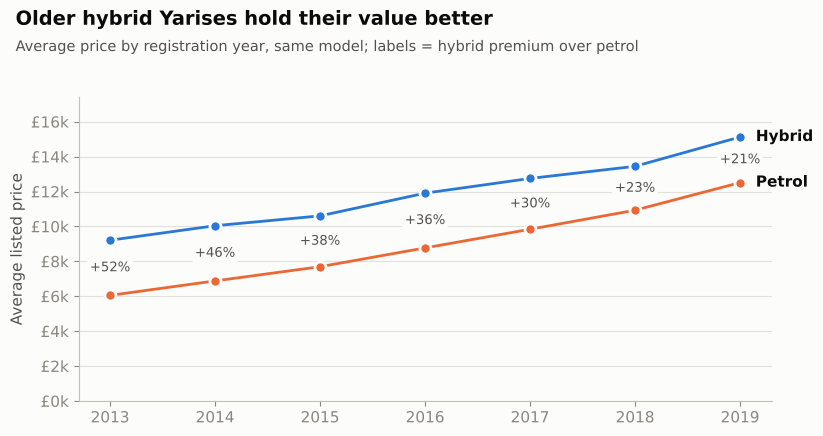

In [13]:
# Chart 1: Yaris hybrid vs petrol average price by registration year (same model, same year)
yh = hyb[hyb.model == 'Yaris'].sort_values('year')
fig, ax = plt.subplots(figsize=(9, 4.6))
fig.subplots_adjust(top=0.78, left=0.09, right=0.86, bottom=0.12)
ax.plot(yh.year, yh.hybrid_avg_price, color=BLUE, lw=2, marker='o', ms=8, mec=SURFACE, mew=2)
ax.plot(yh.year, yh.petrol_avg_price, color=ORANGE, lw=2, marker='o', ms=8, mec=SURFACE, mew=2)
ax.text(yh.year.iloc[-1] + 0.15, yh.hybrid_avg_price.iloc[-1], 'Hybrid', color=INK, va='center', fontweight='bold')
ax.text(yh.year.iloc[-1] + 0.15, yh.petrol_avg_price.iloc[-1], 'Petrol', color=INK, va='center', fontweight='bold')
for _, r in yh.iterrows():
    ax.text(r.year, (r.hybrid_avg_price + r.petrol_avg_price) / 2, f'+{r.hybrid_premium_pct:.0f}%', ha='center', va='center',
            color=INK2, fontsize=9.5, bbox=dict(boxstyle='round,pad=0.2', fc=SURFACE, ec='none'))
ax.set_ylabel('Average listed price')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'£{v/1000:.0f}k'))
ax.set_ylim(0, yh.hybrid_avg_price.max() * 1.15)
ax.set_xticks(yh.year)
clean(ax)
title(fig, 'Older hybrid Yarises hold their value better',
      'Average price by registration year, same model; labels = hybrid premium over petrol')
fig.savefig(IMG / 'yaris_hybrid_vs_petrol.png', dpi=160)
plt.show()

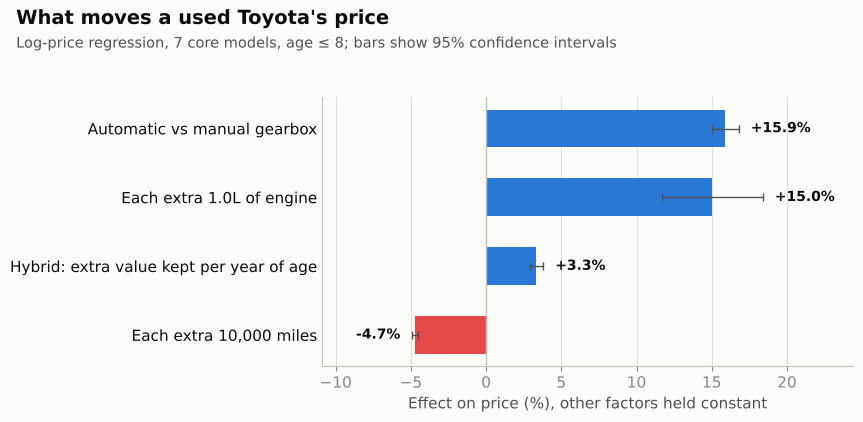

In [14]:
# Chart 2: what moves price (regression effects, diverging blue = adds value, red = removes value)
eff = effects.copy()
eff = eff.drop(index='Hybrid at age 0')   # not significant; explained in the text
eff = eff.sort_values('effect_pct')
fig, ax = plt.subplots(figsize=(9, 4.2))
fig.subplots_adjust(top=0.76, left=0.36, right=0.95, bottom=0.12)
colors = [BLUE if v > 0 else RED for v in eff.effect_pct]
ax.barh(eff.index, eff.effect_pct, color=colors, height=0.55,
        xerr=[eff.effect_pct - eff.ci_low, eff.ci_high - eff.effect_pct],
        error_kw={'ecolor': INK2, 'elinewidth': 1, 'capsize': 3})
for i, (v, lo_, hi_) in enumerate(zip(eff.effect_pct, eff.ci_low, eff.ci_high)):
    x = hi_ + 0.8 if v > 0 else lo_ - 0.8
    ax.text(x, i, f'{v:+.1f}%', va='center', ha='left' if v > 0 else 'right',
            color=INK, fontweight='bold', fontsize=10)
ax.axvline(0, color=BASE, lw=1)
ax.set_xlim(eff.ci_low.min() - 6, eff.ci_high.max() + 6)
ax.set_xlabel('Effect on price (%), other factors held constant')
ax.tick_params(axis='y', colors=INK, length=0)
clean(ax, grid_axis='x')
title(fig, 'What moves a used Toyota\'s price', 'Log-price regression, 7 core models, age ≤ 8; bars show 95% confidence intervals')
fig.savefig(IMG / 'price_drivers.png', dpi=160)
plt.show()

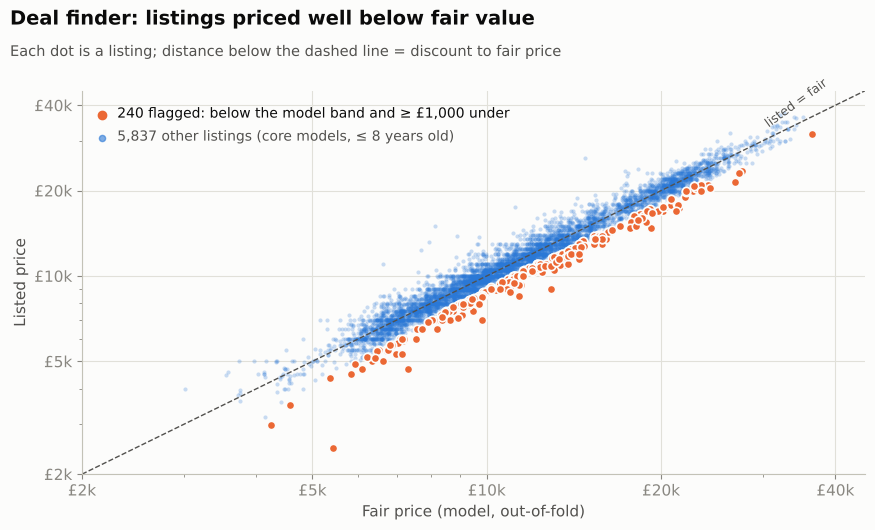

In [15]:
# Chart 3: listed price vs fair price, flagged deals highlighted
fig, ax = plt.subplots(figsize=(9, 5.4))
fig.subplots_adjust(top=0.82, left=0.1, right=0.97, bottom=0.11)
rest = stock.drop(deals.index)
ax.scatter(rest.fair_price, rest.price, s=9, color=BLUE, alpha=0.25, linewidths=0)
ax.scatter(deals.fair_price, deals.price, s=36, color=ORANGE, edgecolors=SURFACE, linewidths=1.2)
lim = [2000, 45000]
ax.plot(lim, lim, color=INK2, lw=1, ls='--')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lim); ax.set_ylim(lim)
fmt = plt.FuncFormatter(lambda v, _: f'£{v/1000:.0f}k')
for a in (ax.xaxis, ax.yaxis):
    a.set_major_formatter(fmt); a.set_minor_formatter(plt.NullFormatter())
ticks = [2000, 5000, 10000, 20000, 40000]
ax.set_xticks(ticks); ax.set_yticks(ticks)
ax.set_xlabel('Fair price (model, out-of-fold)'); ax.set_ylabel('Listed price')
ax.text(30000, 33500, 'listed = fair', color=INK2, fontsize=9, rotation=36)
ax.text(0.045, 0.93, f'{len(deals)} flagged: below the model band and ≥ £1,000 under', transform=ax.transAxes, color=INK, fontsize=10)
ax.text(0.045, 0.87, f'{len(rest):,} other listings (core models, ≤ 8 years old)', transform=ax.transAxes, color=INK2, fontsize=10)
ax.scatter([0.025], [0.937], transform=ax.transAxes, s=36, color=ORANGE, zorder=5)
ax.scatter([0.025], [0.877], transform=ax.transAxes, s=20, color=BLUE, alpha=0.6, zorder=5)
clean(ax, grid_axis='both')
title(fig, 'Deal finder: listings priced well below fair value', 'Each dot is a listing; distance below the dashed line = discount to fair price')
fig.savefig(IMG / 'deal_finder.png', dpi=160)
plt.show()

## 8. Conclusions and limitations

| Question | Answer |
|---|---|
| What is a car worth? | The gradient-boosting model prices **77% of listings within £1,000** (MAE ~£740), out-of-fold, with an honest ±range that covers ~80% of listings. |
| What drives value? | Automatic **+16%**, each 10k miles **-4.7%**, petrol Yaris **-9.5%/year** at constant mileage. A hybrid's value loss is **~3.3 points per year slower**. |
| Where are the opportunities? | A short, ranked list of recent listings (core models only) sits well below fair value and is worth a human check. Older hybrids are undervalued by a petrol-style depreciation rule. |

**Limitations**
- These are **listing prices, not sale prices**. Negotiated discounts aren't visible.
- There are **no trim, condition, colour or service-history fields**. That is most of the remaining error, especially for Hilux and Land Cruiser.
- It's a **single snapshot (around 2020)**. Absolute £ levels have moved since (UK used-car prices rose sharply in 2021-22), but the *relative* effects are the transferable part.
- The hybrid and automatic effects are partly entangled, because every hybrid is automatic. The automatic premium is estimated from petrol automatics.